## 03 · Emerging issues, prioritisation, monitoring

### Analytical question
Which issues are *growing*, and which should the ops lead look at first this week?

### Evidence so far
Notebook 02: every message has a category or sits in the review queue.

### Why this approach?
Emergence is measured relative to total volume (a marketing push lifts every category) with a Poisson test on the recent count. Priority = share × severity × growth × confidence, with the severity rubric written down and versioned.

/tmp/ipykernel_1058/4102433527.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  (counts.div(counts.sum(1), axis=0)).plot(figsize=(11,4), title='Weekly category share'); plt.legend(bbox_to_anchor=(1,1)); plt.tight_layout()


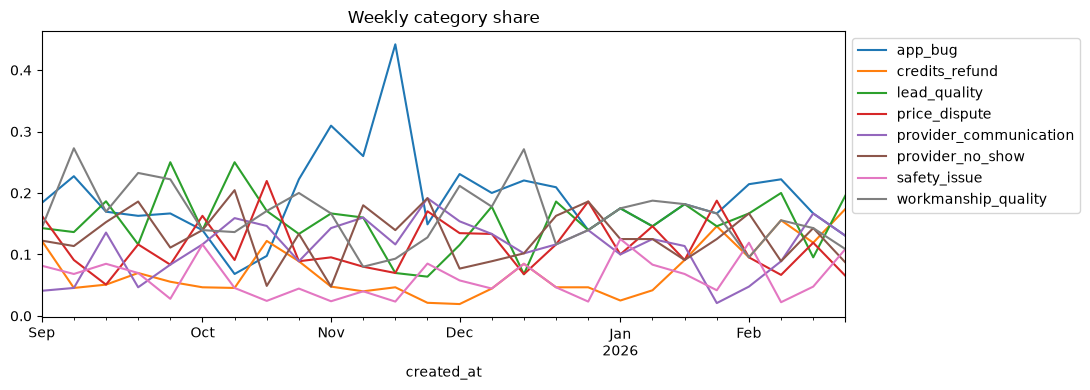

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
counts = pd.read_csv('outputs/project2/weekly_counts.csv', index_col=0, parse_dates=True)
(counts.div(counts.sum(1), axis=0)).plot(figsize=(11,4), title='Weekly category share'); plt.legend(bbox_to_anchor=(1,1)); plt.tight_layout()

In [2]:
pd.read_csv('outputs/project2/emerging_issues.csv')

,category,recent_count,baseline_count,expected_recent,rate_ratio,p_value,q_value,emerging
0,credits_refund,24,31,9.7,2.39,0.0001,0.0008,True
1,lead_quality,29,75,23.3,1.24,0.1435,0.5740,False
2,safety_issue,13,34,10.7,1.21,0.2755,0.7347,False
3,provider_no_show,21,74,23.0,0.91,0.6924,0.9411,False
4,provider_communication,19,69,21.5,0.89,0.7335,0.9411,False
5,app_bug,32,118,36.6,0.88,0.8000,0.9411,False
6,workmanship_quality,22,92,28.6,0.77,0.9125,0.9411,False
7,price_dispute,15,69,21.5,0.70,0.9411,0.9411,False


In [3]:
pd.read_csv('outputs/project2/priorities.csv', index_col=0)

,share,confidence,rate_ratio,emerging,severity,growth,priority,rank
category,,,,,,,,
credits_refund,0.137,0.901,2.39,True,4,2.39,1.181,1
lead_quality,0.166,0.842,1.24,False,3,1.24,0.519,2
app_bug,0.183,0.760,0.88,False,3,1.00,0.417,3
safety_issue,0.074,0.900,1.21,False,5,1.21,0.404,4
provider_no_show,0.120,0.762,0.91,False,4,1.00,0.366,5
price_dispute,0.086,0.781,0.70,False,4,1.00,0.268,6
provider_communication,0.109,0.810,0.89,False,3,1.00,0.264,7
workmanship_quality,0.126,0.850,0.77,False,2,1.00,0.214,8


### Interpretation
`credits_refund` is flagged as emerging (rate ratio ≈ 2.7, p < 0.001) and rises to the top of the priority list despite not being the most frequent category — severity and growth outweigh raw volume. The output names the owner (finance ops) and the action.

### Decision
This table, plus the redacted examples and the review queue, is the weekly operational deliverable. Monitoring watches category-share drift and the size of the review queue (both in `summary.json`).